In [4]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Repacing blanks with 0 as tenure is 0 and no total charges are recorded

In [12]:
df["TotalCharges"]= df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
df["customerID"].duplicated().sum()

np.int64(0)

#converted 0 and 1 values of Senior Citizens to yes/no to make it easier to understand 

In [22]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"]= df["SeniorCitizen"].apply(conv)

<function matplotlib.pyplot.show(close=None, block=None)>

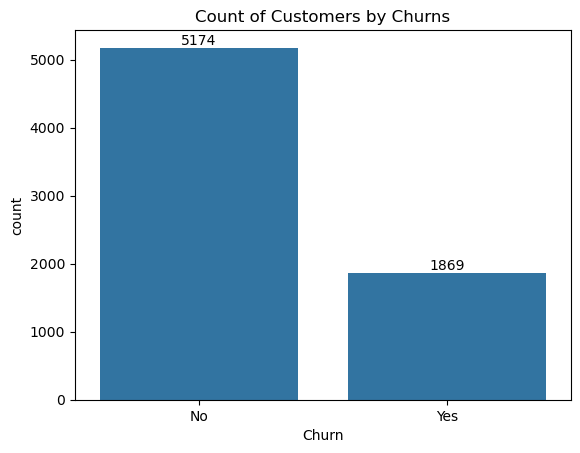

In [32]:
ax = sns.countplot(x= 'Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churns")
plt.show

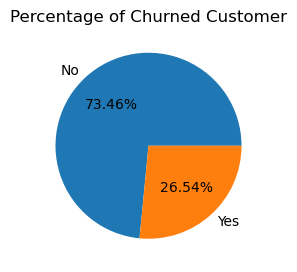

In [34]:
plt.figure(figsize=(3,4))
gb = df.groupby("Churn").agg({'Churn' : "count"})
plt.pie(gb['Churn'], labels= gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customer")
plt.show()

#From the given pie chart we can conclude that 26.54% of our customers have churned out.
#Now let Explore the reason behind it

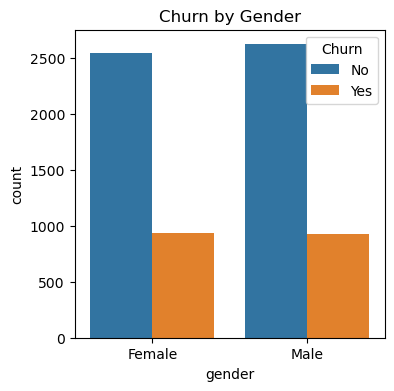

In [39]:
plt.figure(figsize=(4,4))
sns.countplot(x="gender" , data = df, hue="Churn")
plt.title("Churn by Gender")
plt.show()

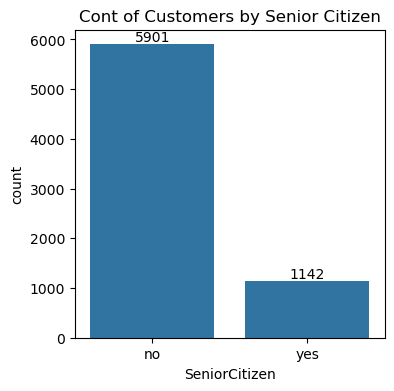

In [44]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="SeniorCitizen" , data = df)
ax.bar_label(ax.containers[0])
plt.title("Cont of Customers by Senior Citizen")
plt.show()

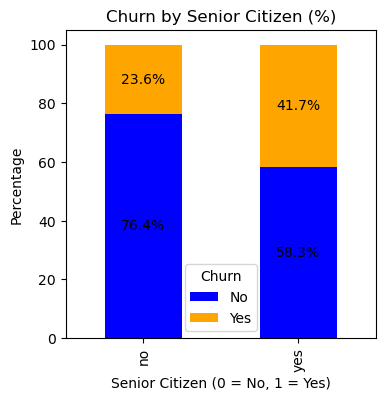

In [45]:
# Crosstab and convert to %
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# Plot
ax = ct.plot(kind='bar', stacked=True, color=['blue', 'orange'], figsize=(4,4))

# Add % labels
for i in range(len(ct)):
    cum = 0
    for val in ct.iloc[i]:
        ax.text(i, cum + val/2, f"{val:.1f}%", ha='center', va='center')
        cum += val

plt.title("Churn by Senior Citizen (%)")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

#comparative a greater percentage of people in senior citizen category have churned

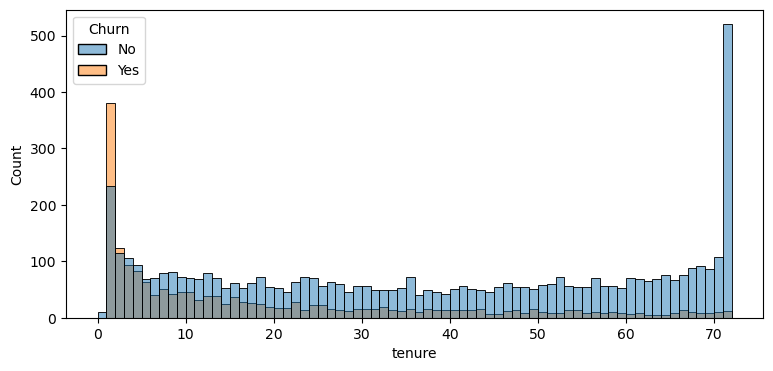

In [48]:
plt.figure(figsize=(9,4))
sns.histplot(x= "tenure",data=df, bins=72, hue = "Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our services 1 or 2 months have churned

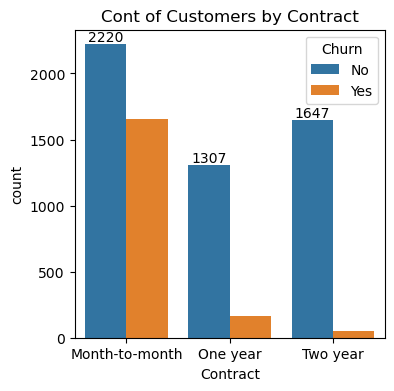

In [50]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="Contract" , data = df, hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Cont of Customers by Contract")
plt.show()

#people who have month to month contract  are likely to churn than from those who have 1 or 2 years of contract

In [52]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

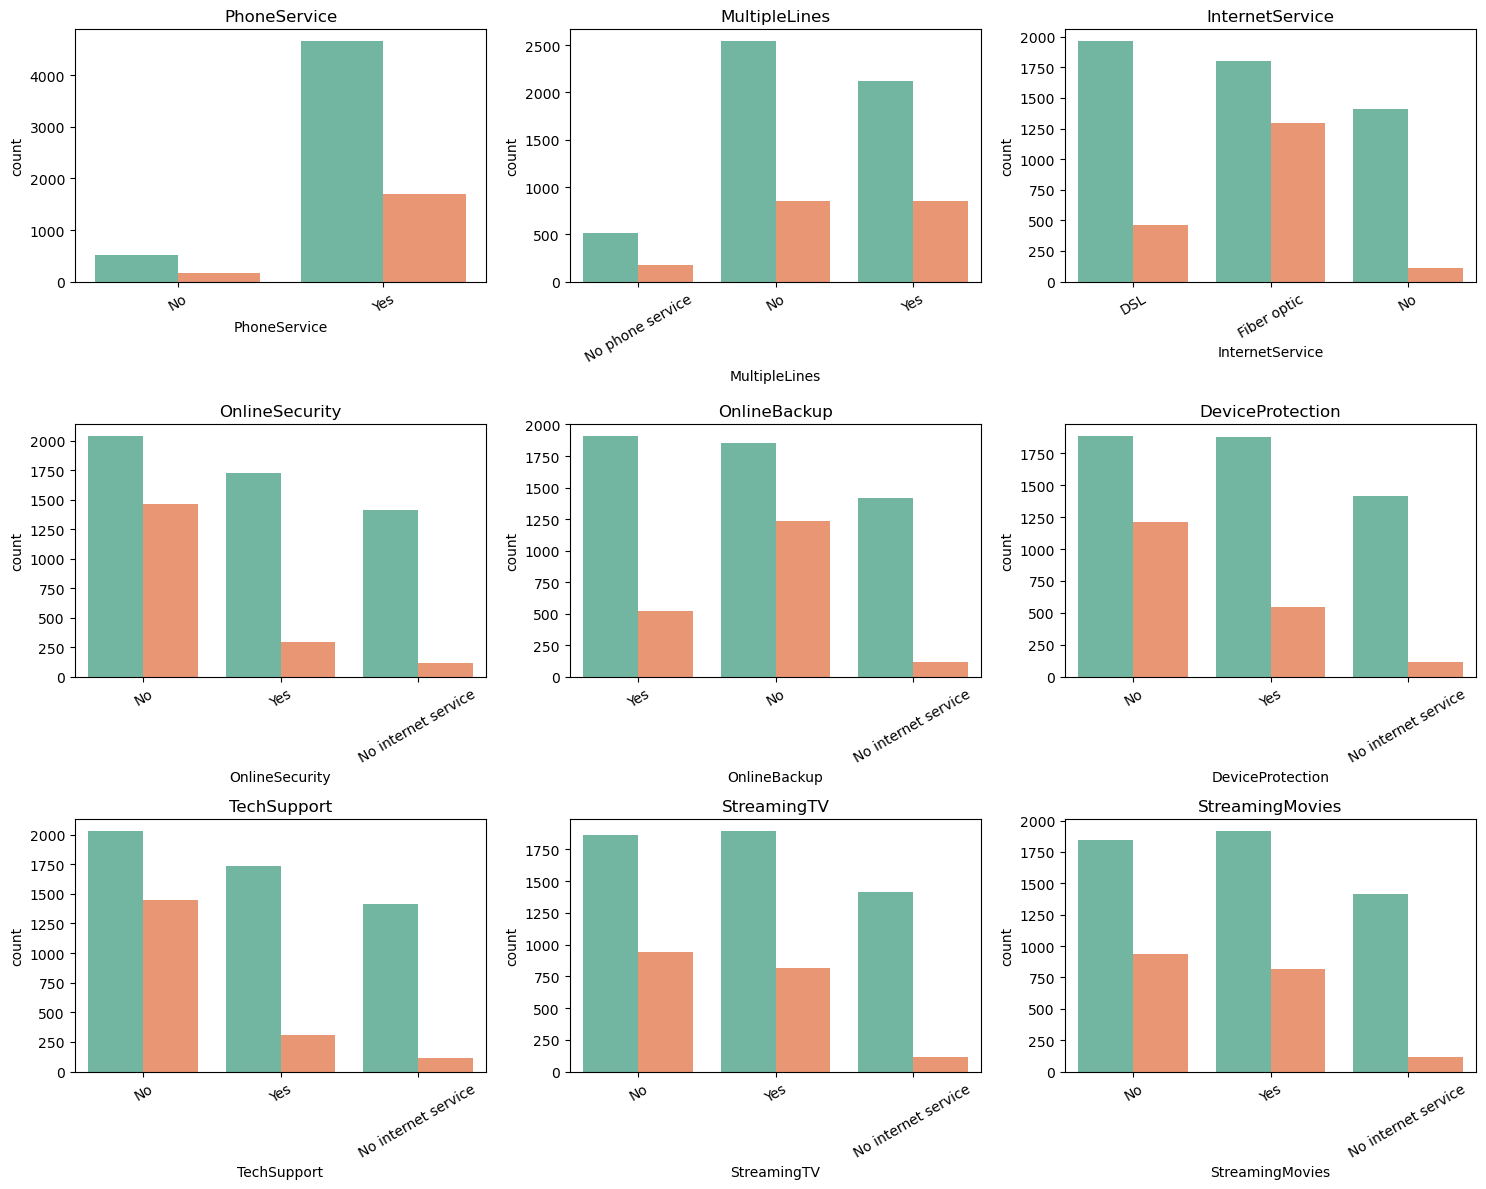

In [55]:
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, hue=df["Churn"], ax=axes[i],
                  palette='Set2', legend=False)
    
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

The data shows that while customers using basic telecom services like phone service and multiple lines form the majority, a noticeable portion of them still churn. A clear pattern emerges where customers who do not use add-on services such as online security, tech support, and device protection are more likely to leave, indicating the importance of these services in customer retention. Additionally, users with fiber optic internet exhibit relatively higher churn compared to DSL users, suggesting possible dissatisfaction despite better connectivity. Overall, the absence of value-added services and certain service types plays a key role in increasing customer churn.

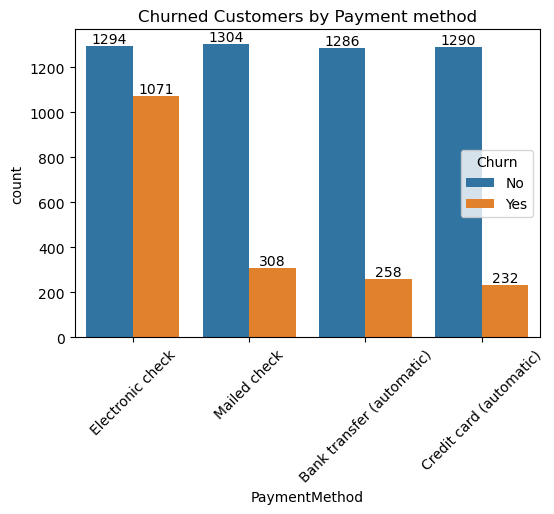

In [9]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x= "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment method")
plt.xticks(rotation = 45)
plt.show()

#Customer is likely to churn when he using electronics check as a payment method.